### Bibliotecas utilizadas

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.tree import plot_tree
from dtreeviz import model
from xgboost import XGBClassifier


### Dataset creditcard.csv

* As colunas de V1 a V28 foram anonimizadas por questões de confidencialidade e privacidade dos titulares, o Google/Kaggle aplicou uma técnica de Machine Learning chamada Análise de Componentes Principais (PCA). Elas representam atributos complexos da transação (como localização, IP, tipo de vendedor).

* Class: variável que se tenta prever.

(Encontrar padrões que diferencie operações normais de operações fraudelentas)

In [3]:
URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df_creditcard = pd.read_csv(URL)
df_creditcard.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Verificando a proporção de cada tipo da transação (fraude e não fraude)

- Aqui foi verificado que o dataset é desbalanceado
Este arquivo **creditcard.csv** é famoso na ciência de dados justamente por ser altamente desbalanceado. Menos de \(0{,}17\%\) do total de registros são fraudes, o que exige técnicas especiais para treinar modelos de Inteligência Artificial sem que eles apenas "adivinhem" tudo como transação normal.

- Como as fraudes são raras: o modelo pode ignorar a classe 1.
- Desbalanceamento: Quando uma classe aparece mais do que agora, no caso, há muito mais exemplos de não fraude.
- O modelo pode aprender errado e nunca detectar as fraudes.
- Acurácia: porcentagem de acertos do modelo.
- Neste caso, a acurária será alta mas será enganosa. Portanto em problemas desbalanceados devemos usar outras métricas, como Recall.
- Recall: mede quantas fraudes o modelo consegue identificar.
- Precision: mede se o que o modelo apontou como uma fraude é realmente fraude.

In [4]:
# Calculando proporção de cada tipo de transação.
df_creditcard['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

### Feature Engineering
- Quando criamos/ou transformamos variáveis que ajudam o modelo a aprender melhor. Melhoram a análise e desempenho do modelo.
- Features: Variáveis do dataset.

### Utilizando log

- Os valores das transações financeiras em *Amount* variam muito e essa diferença enorme de escala atrapalha o modelo, pois ele tende a dar muito mais importância para números grandes. 
- Usando o ***np.log1p***: Aplicamos uma transformação logarítmica que comprime esses valores, deixando-os mais próximos entre si, tornando esses valores mais equilibrados.
- Essa técnica é comumente utilizada em dados financeiros justamente pelo fato dos valores de transações costumarem ter uma variação enorme.

In [5]:
df_creditcard['Amount_log'] = np.log1p(df_creditcard['Amount'])

### Padronizando alguns dados

- Ajustamdo os dados para uma escala comum (melhorar o desempenho do modelo)
- Transforma os dados para que tenha a Média: 0 e o Desvio Padrão: 1.
- Na prática: Os valores ficam na mesma escala e os variáveis passam a ter o mesmo peso.

In [6]:
scaler = StandardScaler()
df_creditcard['Amount_Scaled'] = scaler.fit_transform(df_creditcard[['Amount']])

In [28]:
df_creditcard.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_log,Amount_Scaled
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,0.244964
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,-0.342475
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,1.160686
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,0.140534
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,-0.073403


### Preparando os dados para o treinamento do modelo

- x:representa todas as features/ variáveis de entrada (menos a Class)
- axis=1 trabalha nas colunas/ na direção das linhas/ desce ↓
- y: representa o nosso target/ o que queremos prever
- 30% do dados vão para teste/ o restante para treino
- random: garantir que a divisão seja sempre a mesma sempre que o código for rodado 
- stratify: garanti que a proporção de fraudes e de não fraudes sejam mantidas (tanto no teste quanto no treino (desbalanceado))

In [7]:
x = df_creditcard.drop("Class", axis=1)
y = df_creditcard['Class']

x_train, x_test, y_train, y_test = train_test_split(  
    x, y, stratify=y, test_size=0.3, random_state=42
)

### Regressão Logística

- Modelo de classificação usado para prever categorias, aqui no exemplo: prever se é fraude(1) ou não fraude(0).
- Um dos modelos mais simples, geralmente utilizado inicialmente e serve como referência para outros modelos que possam vir a ser utilizados.

Após rodar foi dado uma aviso: significa que o modelo não conseguiu terminar de aprender dentro do limite de tentativas definido (1000 iterações).
   Para resolver: aumentar o número de iterações ((max_iter=5000)) OU escalar ps dados (usar o código abaixo antes do modelo):
            
            scaler = StandardScaler()
            x_train_scaled = scaler.fit_transform(x_train)
            x_test_scaled = scaler.transform(x_test) 

In [14]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)   

c:\Taita Geral\1. CURSOS\Dio_Bootcamp_Accenture_2026\Projeto_Deteccao_Fraudes\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


In [15]:
# Verificando como o modelo se saiu mesmo com aviso:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.67      0.75       148

    accuracy                           1.00     85443
   macro avg       0.93      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



### Entendendo o resultado do modelo:

As colunas:
    
    - Precision: Das vezes que o modelo disse "é fraude", quantas eram de fato fraude?
    - Recall: Das fraudes reais, quantas o modelo conseguiu detectar?
    - F1-score: Média entre precision e recall (nota geral)
    - Support: Quantidade real de casos

As linhas:
    
    - Classe 0 (transação normal) — 85.295 casos.
    - O modelo foi perfeito — acertou todas as transações normais. ✅
    - Classe 1 (fraude) — 148 casos.

    - Precision 0.85 → quando disse "é fraude", acertou 85% das vezes ✅.
    - Recall 0.67 → das 148 fraudes reais, detectou apenas 67% ⚠️.
    - Ou seja, deixou passar ~33% das fraudes sem detectar.

⚠️ O modelo acertou quase tudo porque 99% dos dados são transações normais. Ele "aprendeu" que o mais seguro é dizer "normal" — e quase sempre acerta.
Mas no contexto de detecção de fraude, o Recall da classe 1 é o mais importante — e 0.67 significa que 1 em cada 3 fraudes passou despercebida.

Resumindo:
    - Transações normais → 🟢 Perfeito.
    - Detecção de fraudes → 🟡 Razoável, pode melhorar.

⚠️ Isso é muito comum em datasets desbalanceados (como é o caso). 

### Métrica: Curva ROC (Mede a capacidade do modelo de separar fraude de transação normal)

- Métrica importante utilizada em modelos de classificação.
- False Positive Rate: Taxa de falsos positivos, quantas transações normais foram classificadas como fraude.
- True Positive Rate: Quantas fraudes o modelo realmente identificou.
- Quanto mais a curva se aproxima do canto superior esquerdo, melhor é o modelo: alto recall e baixo erro.
- Se a curva for uma linha reta diagonal o modelo seria aleatório, não seria capaz de distinguir fraude ou não fraude.
- AUC: Valor próximo de 1 indica que o modelo está muito bom, próximo a 0.5 modelo aleatório.

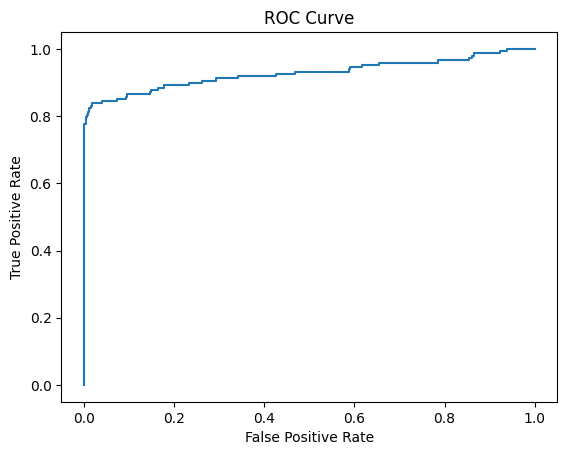

AUC: 0.9273972049310582


In [16]:
y_probs = model.predict_proba(x_test)[:,1]
fpr, tpr, _ =roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

### Métrica: Precision-Recall Curve (Mostra o equilíbrio entre Precision e Recall)

- Métrica mais importante utilizada em datasets desbalanceados como neste de fraude.
- Recall: quantas fraudes o modelo consegue identificar.
- Precision: quantas fraudes são realmente fraudes.

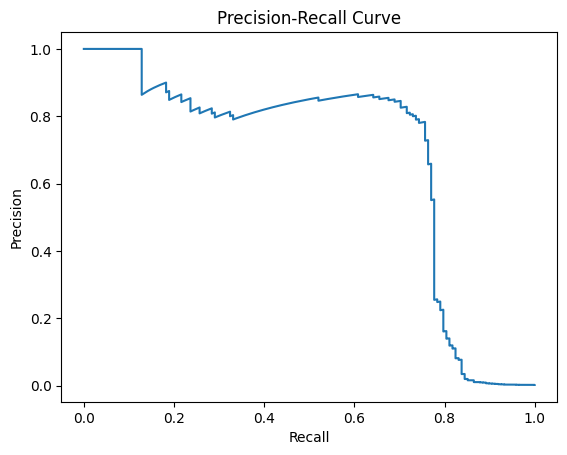

In [17]:
precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

### Formas de atuar em datasets com dados desbalanceados

### Undersampling

- Cria um dataset equilibrado, com a mesma quantidade de transações normais e fraudes.
- A classe majoritário (no caso, classe de transações normais) é reduzida para o mesmo tamanho da classe minoritária (classe de transações de fraudes).
- Problema: Perda de muitos dados normais, reduzindo a qualidade dos dados.

In [ ]:
fraudes = df_creditcard[df_creditcard["Class"]==1]
normais = df_creditcard[df_creditcard["Class"]==0].sample(len(fraudes), random_state=42)

df_creditcard_under = pd.concat([fraudes, normais])

In [ ]:
print(f"Dimensão do Dataset original: {df_creditcard.shape}")
print(f"Dimensão do Dataset undersampling: {df_creditcard_under.shape}")

Dimensão do Dataset original: (284807, 33)
Dimensão do Dataset undersampling: (984, 33)


In [63]:
x = df_creditcard_under.drop("Class", axis=1)
y = df_creditcard_under['Class']

x_train, x_test, y_train, y_test = train_test_split(  
    x, y, stratify=y, test_size=0.3, random_state=42
)

model_under = LogisticRegression(max_iter=1000)
model_under.fit(x_train, y_train)

y_pred_under = model_under.predict(x_test)

print(classification_report(y_test, y_pred_under))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       148
           1       0.95      0.93      0.94       148

    accuracy                           0.94       296
   macro avg       0.94      0.94      0.94       296
weighted avg       0.94      0.94      0.94       296



c:\Taita Geral\1. CURSOS\Dio_Bootcamp_Accenture_2026\Projeto_Deteccao_Fraudes\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


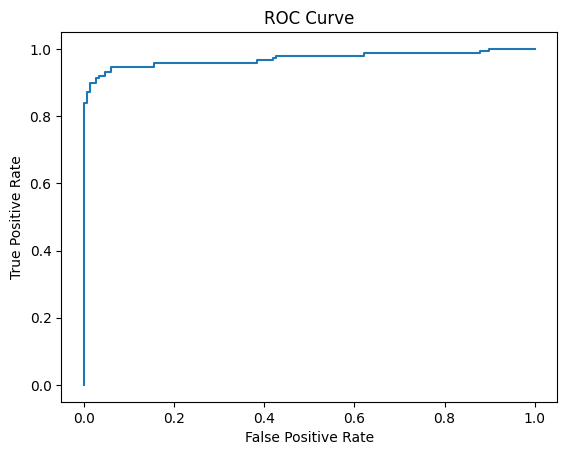

AUC: 0.970735938641344


In [64]:
y_probs_under = model_under.predict_proba(x_test)[:,1]
fpr, tpr, _ =roc_curve(y_test, y_probs_under)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs_under))

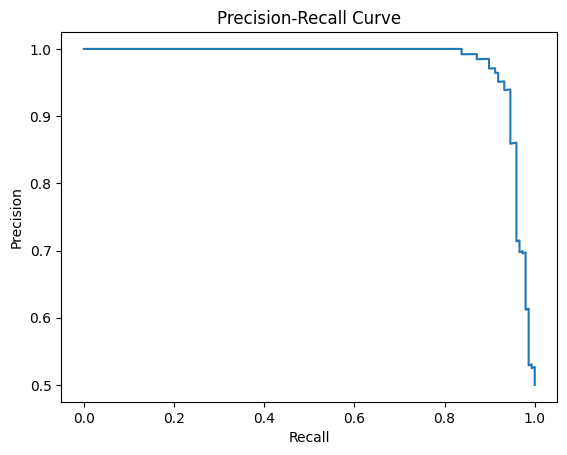

In [65]:
precision, recall, _ = precision_recall_curve(y_test, y_probs_under)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

`Considerações importantes - Após o Undersampling:`

> O Recall que era de 0.67⚠️ foi para 0.93 ✅.

> F1-score fraudes passou de 0.75 para 0.94.

Usar o undersampling foi bom, mas ele considerou apenas 296 casos no total e jogou fora o restante das informações.

**Métrica ROC Curve**

- A curva sobe bem, mas de forma mais gradual e com pequenos degraus: Isso acontece justamente porque tem poucos dados para testar.

**Métrica Precision-Recall Curve**

- A curva aqui aparece uma queda em degraus a partir de 0.8 de Recall: Indica que com poucos dados o modelo fica menos confiante nas bordas.

### Oversampling

- Também cria um dataset equilibrado, com a mesma quantidade de transações normais e fraudes.
- Cria novos exemplos sintéticos da classe minoritária (trasações fraudes).
- Gera novos dados (novas fraudes) baseadas nas já existentes.
- Ponto positivo: Não há perda de dados, e a representação da classe minoritária aumenta.
- Ponto negativo: Dados gerados são artificiais.

In [57]:
smote = SMOTE()
x_res, y_res = smote.fit_resample(x, y)

Após smote:
- Dividir novamente em teste e treino.
- Treinar o modelo novamente.
- Fazer novas previsões.
- Visualizar os novos resultados.

In [58]:
x_train, x_test, y_train, y_test = train_test_split(
    x_res, y_res, stratify=y_res, test_size=0.3, random_state=42
)

model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(x_train, y_train)

y_pred_smote = model_smote.predict(x_test)

print(classification_report(y_test, y_pred_smote))

c:\Taita Geral\1. CURSOS\Dio_Bootcamp_Accenture_2026\Projeto_Deteccao_Fraudes\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.97      0.99      0.98     85295
           1       0.99      0.97      0.98     85294

    accuracy                           0.98    170589
   macro avg       0.98      0.98      0.98    170589
weighted avg       0.98      0.98      0.98    170589



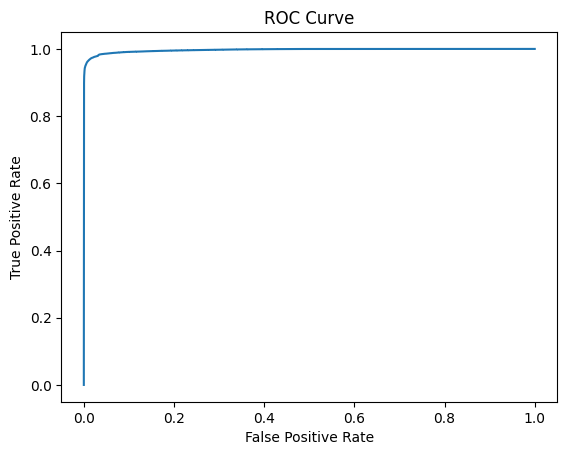

AUC: 0.9967373079791423


In [59]:
y_probs_smote = model_smote.predict_proba(x_test)[:,1]
fpr, tpr, _ =roc_curve(y_test, y_probs_smote)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs_smote))

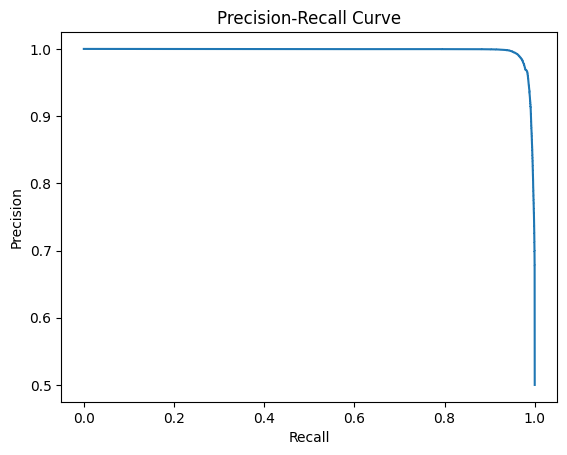

In [60]:
precision, recall, _ = precision_recall_curve(y_test, y_probs_smote)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

`Considerações importantes - Após o Smote:`

> O Recall que era de 0.67⚠️ foi para 0.97 ✅.

> F1-score fraudes passou de 0.75 para 0.98.

O modelo passou a detectar 97% das fraudes, antes deixava passar 1 em cada 3, agora quase nenhuma passa! E os dois grupos ficaram equilibrados com 85.294 casos cada.

**Métrica ROC Curve**

- A curva sobe rapidamente para o canto superior esquerdo: ótimo resultado!
- Quanto mais próxima desse canto, melhor o modelo

**Métrica Precision-Recall Curve**

- A linha se mantém alta e estável por quase todo o gráfico.
- Só cai levemente no final, quando o Recall chega perto de 1.0: significa que o modelo consegue ser preciso e abrangente ao mesmo tempo.


### Random Forest

- Um dos mais populares e poderoso modelo de Machine Learning.
- Cria várias árvores de decisão onde cada uma aprende um padrão diferente dos dados e no final o modelo combina todos esses resultados.
- Lida melhor com dados desbalanceados e captura padrões mais complexos nas transações.

In [18]:
rf = RandomForestClassifier(
    n_estimators=50,  # definindo 50 árvores
    max_depth=10,     # limitando a profundidade da árvore, evitar overfiting
    class_weight="balanced",    # ajusta automaticamente o peso das classes
    n_jobs=-1,        
    random_state=42
)

rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



### Entendendo o resultado do modelo:
  
    - Classe 0 (transação normal) — 85.295 casos.
    - O modelo foi perfeito — acertou todas as transações normais. ✅
    - Classe 1 (fraude) — 148 casos.

    - Precision 0.84 → quando disse "é fraude", acertou 84% das vezes ✅ (no modelo anterior foi 85%).
    - Recall 0.76 → das 148 fraudes reais, detectou 76% das fraudes ⚠️ (no modelo anterior foi 67%).
    - Ou seja, deixou passar ~24% das fraudes sem detectar (no modelo anterior foi ~33%).

Comparado com o modelo anterior, o Random Forest melhorou a capacidade de detectar fraudes.

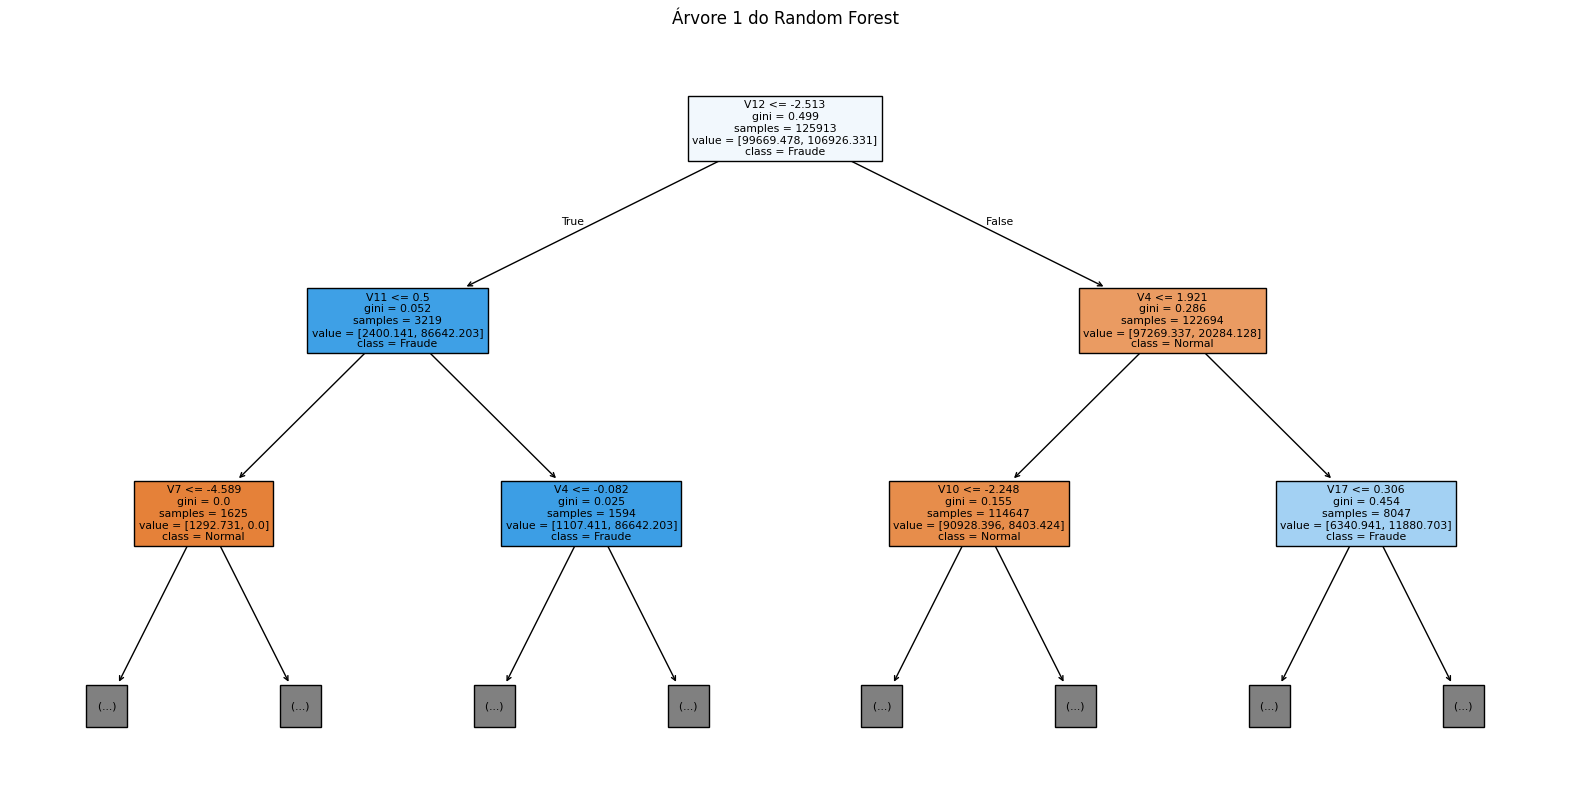

In [19]:
plt.figure(figsize=(20, 10))
plot_tree(
    rf.estimators_[0],  # pega a primeira árvore
    feature_names=x.columns.tolist(),
    class_names=["Normal", "Fraude"],
    filled=True,        # colorida por classe
    max_depth=2         # limita a profundidade para ficar legível
)
plt.title("Árvore 1 do Random Forest")
plt.show()

In [ ]:
# viz = model(
    # rf.estimators_[0],
    # x.values,
    # y.values,
    # feature_names=x.columns.tolist(),
    # class_names=["Normal", "Fraude"]
#)
# viz.view()

Para visualizar as 50 árvores:

```

for i in range(50):
    plt.figure(figsize=(20, 10))
    plot_tree(
        rf.estimators_[i],
        feature_names=x.columns.tolist(),
        class_names=["Normal", "Fraude"],
        filled=True,
        max_depth=3
    )
    plt.title(f"Árvore {i+1} do Random Forest")
    plt.show()
    input(f"Pressione Enter para ver a árvore {i+2}...")  # pausa entre cada uma

```


## Pipeline
- Organizar o fluxo de processamento.

In [ ]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

> O **threshold** define a partir de qual probabilidade considera fraude. O padrão é 0.5 (50%). Neste caso, pode ser interessante baixar esse valor.
> É como regular a sensibilidade do detector: quanto menor o threshold, mais "desconfiado" o modelo fica com as transações.

In [23]:
# alterando para 0.3: menos rigor/ aumentar o recall/ mais sensível a fraudes
threshold = 0.3    

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.70      0.77       148

    accuracy                           1.00     85443
   macro avg       0.92      0.85      0.88     85443
weighted avg       1.00      1.00      1.00     85443



## Modelo XGBoost

- Um dos modelos mais avançados e mais usado em competições e mercado.
- Baseado em bustin: vários modelos simples (geralmente árvores) são treinados em sequência e cada modelo tentar corrigir o modelo anterior/ aprendizado sequencial/ próximas árvores corrigim os erros das anteriores.

In [27]:
xgb = XGBClassifier(
    scale_pos_weight=10,    # ajuda com desbalanceamento
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

print(classification_report(y_test, y_pred_xgb))

c:\Taita Geral\1. CURSOS\Dio_Bootcamp_Accenture_2026\Projeto_Deteccao_Fraudes\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:43:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.93      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.96      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



### Entendendo o resultado do modelo:
  
    - Classe 0 (transação normal) — 85.295 casos.
    - O modelo foi perfeito — acertou todas as transações normais. ✅
    - Classe 1 (fraude) — 148 casos.

    - Precision 0.93 → quando disse "é fraude", acertou 93% das vezes ✅.
    - Recall 0.78 → das 148 fraudes reais, detectou 78% das fraudes ⚠️.
    - Ou seja, deixou passar ~22% das fraudes sem detectar.
    - f1-store → 85%, bom equilíbrio entre precision e recall.

Resultados melhores que os modelos anteriores.

### Entendendo a importância das variáveis do dataset

- Quais variáveis influenciam mais o modelo?

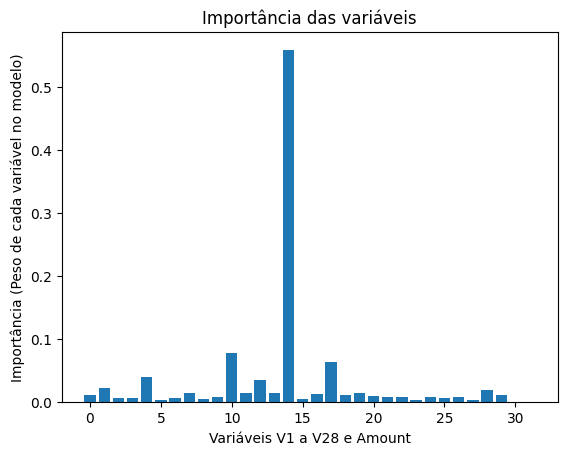

In [31]:
importancia = xgb.feature_importances_

plt.bar(range(len(importancia)), importancia)
plt.title("Importância das variáveis")
plt.xlabel("Variáveis V1 a V28 e Amount")
plt.ylabel("Importância (Peso de cada variável no modelo)")
plt.show()

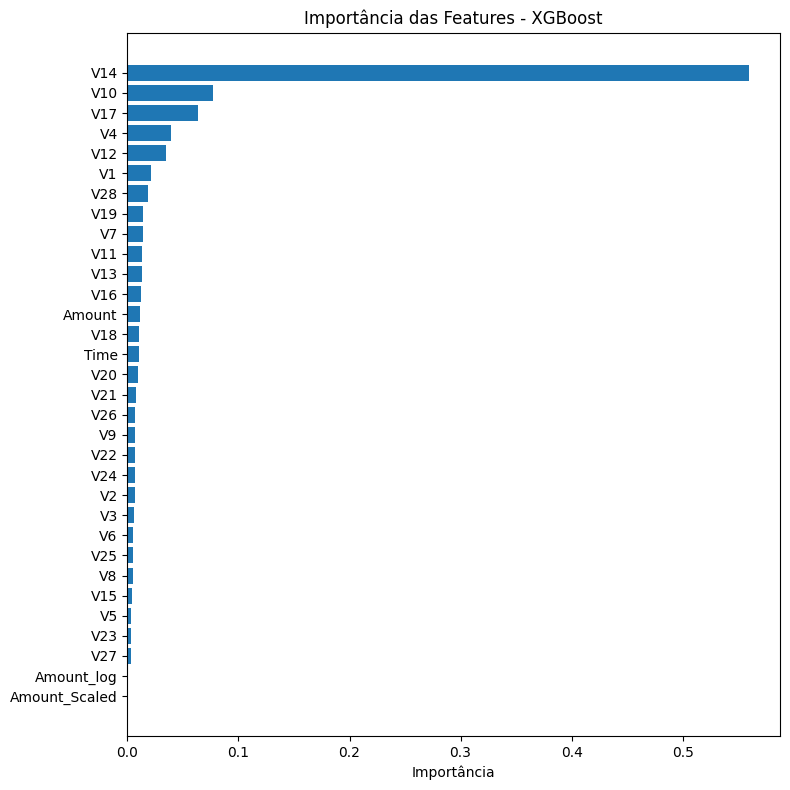

In [33]:
# Criando um DataFrame com nome e importância
df_importancia = pd.DataFrame({
    "Feature": x.columns.tolist(),
    "Importancia": xgb.feature_importances_
})

# Ordenando da mais importante para a menos
df_importancia = df_importancia.sort_values("Importancia", ascending=False)

# Plotando o gráfico
plt.figure(figsize=(8, 8))
plt.barh(df_importancia["Feature"], df_importancia["Importancia"])
plt.xlabel("Importância")
plt.title("Importância das Features - XGBoost")
plt.gca().invert_yaxis()  # mais importante no topo
plt.tight_layout()
plt.show()

In [35]:
print("Valor da Importância das variáveis")
print(df_importancia.to_string(index=False))

Valor da Importância das variáveis
      Feature  Importancia
          V14     0.559736
          V10     0.076968
          V17     0.063595
           V4     0.039389
          V12     0.034364
           V1     0.021461
          V28     0.018902
          V19     0.013968
           V7     0.013890
          V11     0.013432
          V13     0.013145
          V16     0.012065
       Amount     0.010916
          V18     0.010733
         Time     0.010434
          V20     0.009810
          V21     0.008009
          V26     0.007147
           V9     0.007128
          V22     0.007086
          V24     0.007006
           V2     0.006386
           V3     0.005634
           V6     0.005171
          V25     0.005131
           V8     0.004745
          V15     0.004248
           V5     0.003454
          V23     0.003047
          V27     0.003000
   Amount_log     0.000000
Amount_Scaled     0.000000
